In [2]:
import pandas as pd

df = pd.read_csv("/Users/aakashreddy/Desktop/fast-food-restaurant-analysis/data/processed/merged_restaurant_data.csv")

df.head()

,name,city,province,latitude,longitude,state_name,population
0,Wendy's,Washington Court House,OH,39.53255,-83.44526,Ohio,14439
1,Frisch's Big Boy,Maysville,KY,38.62736,-83.79141,Kentucky,8737
2,OMG! Rotisserie,Athens,OH,39.35155,-82.09728,Ohio,23396
3,Domino's Pizza,Hamilton,OH,39.41760,-84.47641,Ohio,63468
4,Domino's Pizza,Englewood,OH,39.86969,-84.29358,Ohio,13356


In [3]:
city_counts = (
    df.groupby(["city", "province", "population"])
      .size()
      .reset_index(name="restaurant_count")
)

city_counts["restaurants_per_10000"] = (
    city_counts["restaurant_count"] /
    city_counts["population"]
) * 10000

In [4]:
highest = city_counts.sort_values(
    "restaurants_per_10000",
    ascending=False
)

highest.head(20)

,city,province,population,restaurant_count,restaurants_per_10000
1763,Middlebury,IN,109,1,91.743119
389,Calumet,IA,113,1,88.495575
2678,Stone Creek,OH,145,1,68.965517
1850,Mormon Lake,AZ,153,1,65.359477
155,Baker,CA,339,2,58.997050
864,Fairview,PA,179,1,55.865922
2111,Palco,KS,197,1,50.761421
2329,Rehoboth Beach,DE,1370,6,43.795620
2715,Sutton,WV,797,3,37.641154
399,Campton,KY,272,1,36.764706


In [5]:
lowest = city_counts.sort_values(
    "restaurants_per_10000"
)

lowest.head(20)

,city,province,population,restaurant_count,restaurants_per_10000
2467,San Francisco,CA,3417736,3,0.008778
408,Cape Coral,FL,675797,1,0.014797
1803,Mission Viejo,CA,647990,1,0.015432
1945,New York,NY,19268388,36,0.018683
593,Concord,CA,531305,1,0.018822
295,Boston,MA,4453352,9,0.020209
321,Bridgeport,CT,945974,2,0.021142
358,Buffalo,NY,934832,2,0.021394
2371,Riverside,CA,2333040,5,0.021431
286,Bonita Springs,FL,452793,1,0.022085


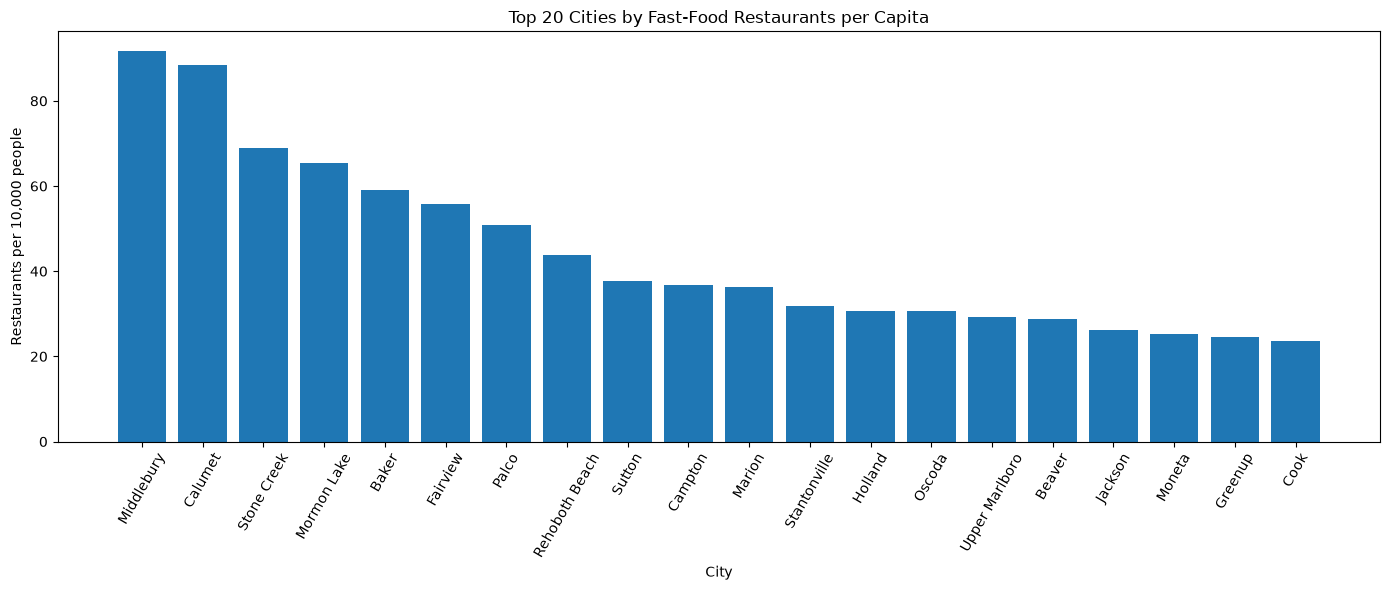

In [7]:
import matplotlib.pyplot as plt

top20 = highest.head(20)

plt.figure(figsize=(14,6))

plt.bar(
    top20["city"],
    top20["restaurants_per_10000"]
)

plt.xticks(rotation=60)
plt.ylabel("Restaurants per 10,000 people")
plt.xlabel("City")
plt.title("Top 20 Cities by Fast-Food Restaurants per Capita")

plt.tight_layout()
plt.savefig(
    "/Users/aakashreddy/Desktop/fast-food-restaurant-analysis/charts/q8_fast_food_restaurants_per_capita.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()